In [1]:
import json
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple, Callable, Dict, Union
import sys

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import scipy

import arviz as az

# src directory
parent_dir = Path.cwd().parent.parent 
sys.path.append(str(parent_dir))

print(parent_dir)
from tools.myutils import plot_act_density, plot_location

/home/pim/pg-rad-analysis/src


## Loading scenario, original parameters and posterior data

The loop below loads all traces for each scenario into `result_dict`, and plots `PLOT_SELECT` scenarios for visualization.

In [4]:
SIM_NAME = ''
SCENE = 'HPGe'
WINDOW_CENTER = 700 # meters
WINDOW_SIZE = WINDOW_CENTER / 2 # meters
SIM_ID = [4.0, 3.5, 3.0, 2.5, 2.0, 1.95, 1.9, 1.85, 1.8, 1.75, 1.7, 1.65, 1.6, 1.55, 1.5, 1.45, 1.4, 1.35, 1.3, 1.25, 1.2, 1.15, 1.1, 1.05, 1.0]
PLOT_SELECT = [4., 3., 2., 1.5, 1.]

In [3]:
SIM_NAME = 'fwhm_NaI_'
SCENE = 'NaIR'
WINDOW_CENTER = 1000
WINDOW_SIZE = WINDOW_CENTER / 2
SIM_ID = [4.0, 4.0] #, 2.0, 1.5, 1.2, 1.0]
PLOT_SELECT = SIM_ID

For plotting: pass the center and the window size on left and right side.

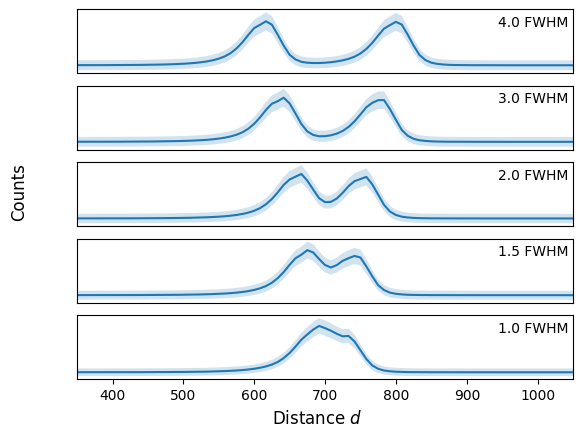

In [5]:
result_dict = {}
SIM_PER_D = 10

fig, axs = plt.subplots(len(PLOT_SELECT))
fig.supxlabel('Distance $d$')
fig.supylabel('Counts')

k = 0

for i, sim in enumerate(SIM_ID):
    traces = []
    for j in range(SIM_PER_D):
        traces.append(az.from_netcdf(f"trace_output/{sim}_{SIM_NAME}trace_{j}"))
        df_i = pd.read_pickle(f"trace_output/{sim}_{SIM_NAME}pkl_{j}")
        with open(f"trace_output/{sim}_{SIM_NAME}real_params_{j}", 'r') as file:
            real_params = json.load(file)
        real_params_i = {int(k):v for k,v in real_params.items()}

    if sim in PLOT_SELECT:
        axs[k].plot(df_i["Dist"], df_i["ROI_P"])
        axs[k].fill_between(df_i["Dist"],
                 df_i["ROI_P"] - np.sqrt(df_i["ROI_P"]),
                 df_i["ROI_P"] + np.sqrt(df_i["ROI_P"]),
                 alpha=0.2)
        axs[k].text(0.99, 0.91, str(sim) +" FWHM", transform=axs[k].transAxes, ha='right', va='top')
        axs[k].set_yticks([])
        axs[k].set_xlim((WINDOW_CENTER-WINDOW_SIZE, WINDOW_CENTER+WINDOW_SIZE))
    
        if k <= (len(PLOT_SELECT) - 2):
            axs[k].set_xticks([])

        k += 1

    result_dict[sim] = {'traces': traces, 'df': df_i, 'real_params': real_params_i}

plt.savefig(f'source-dist-bayesian-test-{SCENE}.png')

## Posterior analysis

In [30]:
ard_list = []
rpd_list = []

for sim in SIM_ID:
    rp = result_dict[sim]['real_params']
    
    real_acts = np.array([rp[1]['act'], rp[2]['act']]).T
    real_x, real_y = np.array([rp[1]['x'], rp[2]['x']]).T, np.array([rp[1]['y'], rp[2]['y']]).T

    ard_ls = []
    rpd_ls = []
    
    for j in range(SIM_PER_D):
        trace = result_dict[sim]['traces'][j]
        posterior = trace.posterior
        x_samples = posterior.x_src.stack(sample=("chain","draw")).transpose("sources","sample").values
        y_samples = posterior.y_src.stack(sample=("chain","draw")).transpose("sources","sample").values
        a_samples = posterior.act_src.stack(sample=("chain","draw")).transpose("sources","sample").values
    
        x_mean = x_samples.mean(axis=1)
        y_mean = y_samples.mean(axis=1)
    
        r_real = np.sqrt(real_x**2 + real_y**2)
        r_est = np.sqrt(x_mean**2 + y_mean**2)
    
        act_mean = a_samples.mean(axis=1)

        ARD = np.abs(act_mean - real_acts) / real_acts * 100
        RPD = np.abs(r_est - r_real) / r_real * 100
    
        ard_ls.append(ARD)
        rpd_ls.append(RPD)

    ard_list.append(ard_ls)
    rpd_list.append(rpd_ls)

ard_arr = np.array(ard_list)
rpd_arr = np.array(rpd_list)

print('ARD shape', ard_arr.shape)
print('RPD shape', rpd_arr.shape)

ARD shape (25, 10, 2)
RPD shape (25, 10, 2)


Along axis 2, we have ARD/RPD of the 2 sources in a single scenario.

With 10 simulations, this means 20 values of ARD/RPD per scenario.

The LP is then defined as the number of ARD/RPD that are below 30%, divided by 20 (2x10).

Thus, to determine the ARD/RPD, we first make a boolean array across the scenarios.

In [31]:
is_located = (ard_arr < 30) & (rpd_arr < 30)

Then, we sum across the 2 sources and 10 scenarios (2x10) and divided by 20 to get the localization probability as a fraction.

In [40]:
print("RPD alone:", (rpd_arr < 30).sum(axis=(1, 2)) / 20))
print("ARD alone:", (ard_arr < 30).sum(axis=(1, 2)) / 20)

RPD alone: [0.95 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   0.9  0.9  0.95 0.95 1.   1.   0.9 ]
ARD alone: [0.9  0.65 0.7  0.7  0.8  0.6  0.65 0.65 0.55 0.55 0.5  0.3  0.1  0.5
 0.1  0.15 0.2  0.   0.05 0.   0.   0.   0.   0.   0.  ]


In [33]:
LP = is_located.sum(axis=(1, 2)) / 20

In [34]:
print('SIM_ID', SIM_ID)
print('LP', LP)

SIM_ID [4.0, 3.5, 3.0, 2.5, 2.0, 1.95, 1.9, 1.85, 1.8, 1.75, 1.7, 1.65, 1.6, 1.55, 1.5, 1.45, 1.4, 1.35, 1.3, 1.25, 1.2, 1.15, 1.1, 1.05, 1.0]
LP [0.85 0.65 0.7  0.7  0.8  0.6  0.65 0.65 0.55 0.55 0.5  0.3  0.1  0.5
 0.1  0.15 0.2  0.   0.05 0.   0.   0.   0.   0.   0.  ]


In [44]:
def logistic(x, A, L, k, x0):
    return A + (L - A) / (1 + np.exp(-k * (x - x0)))

def fit(x, y, points=100):
    x_interp = np.linspace(min(x), max(x), points)
    
    p0 = [
        min(y),   # A
        max(y),   # L
        10,       # k
        1.6       # x0
    ]

    popt, _ = scipy.optimize.curve_fit(logistic, x, y, p0=p0)
    
    return x_interp, logistic(x_fit, *popt)

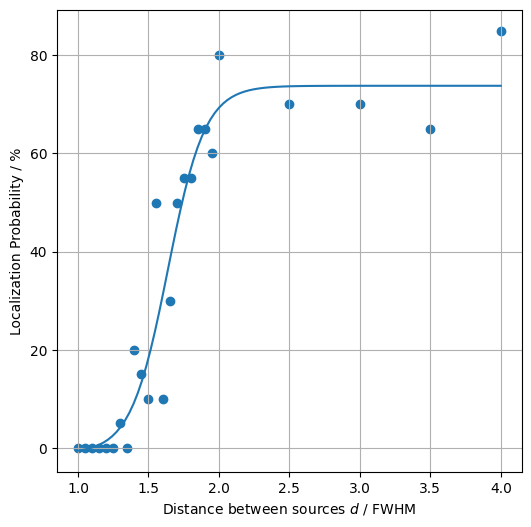

In [56]:
x_fit, y_fit = fit(SIM_ID, LP)

plt.figure(figsize=(6,6))
plt.scatter(SIM_ID, LP * 100)
plt.plot(x_fit, y_fit* 100)
plt.xlabel('Distance between sources $d$ / FWHM')
plt.ylabel('Localization Probability / %')
plt.grid()
plt.savefig(f'2_src_dist_LP_{SCENE}.png')

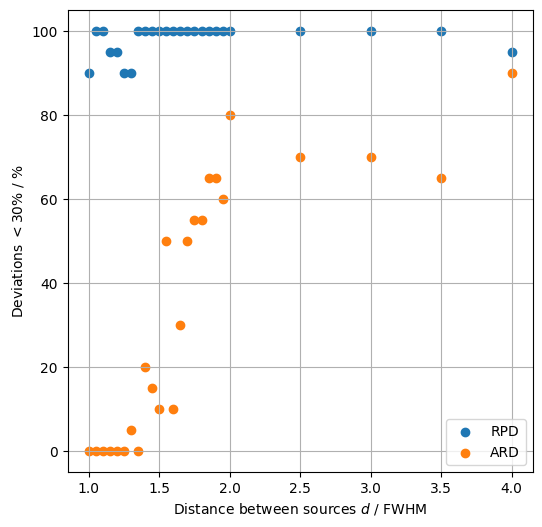

In [57]:
RPD_alone = (rpd_arr < 30).sum(axis=(1, 2)) / 20
# x_fit, y_fit = fit(SIM_ID, RPD_alone)

plt.figure(figsize=(6,6))
plt.scatter(SIM_ID, RPD_alone * 100, label='RPD')
plt.scatter(SIM_ID, ARD_alone * 100, label='ARD')
plt.xlabel('Distance between sources $d$ / FWHM')
plt.ylabel('Deviations $< 30$% / %')
plt.grid()
plt.legend()
plt.savefig(f'2_src_dist_RDs_{SCENE}.png')

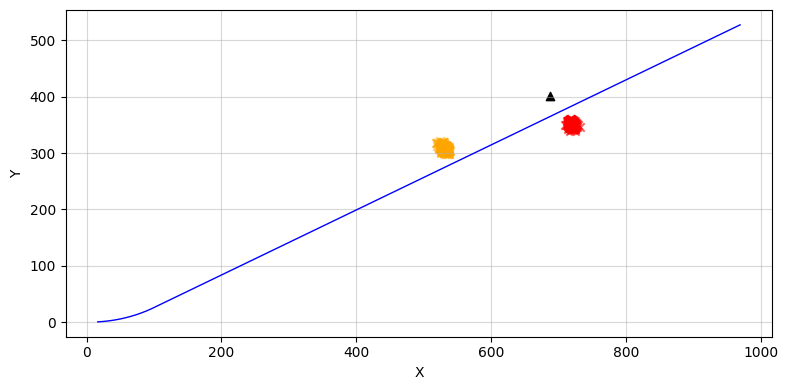

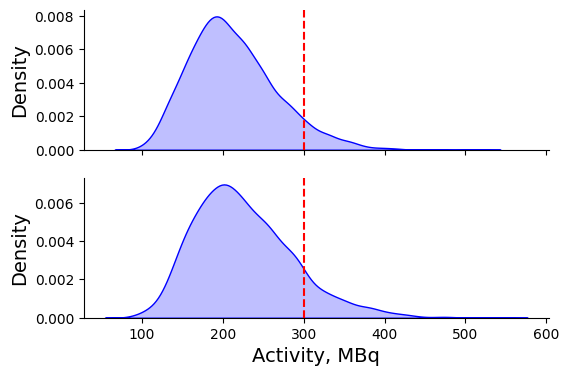

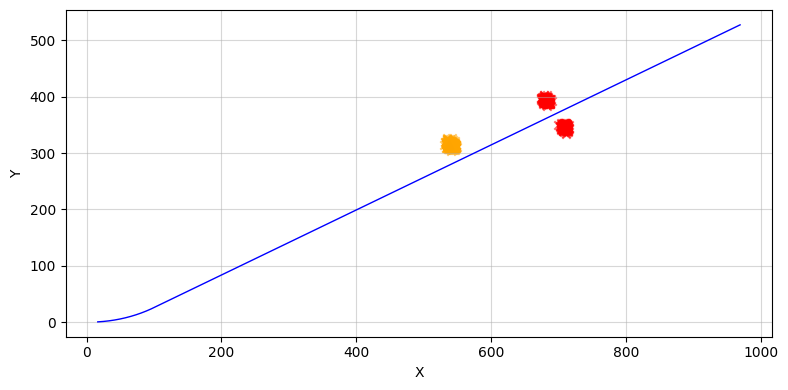

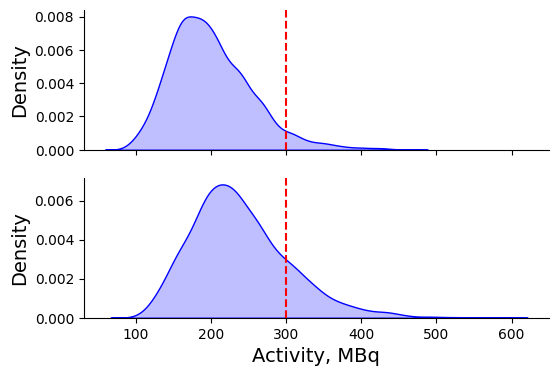

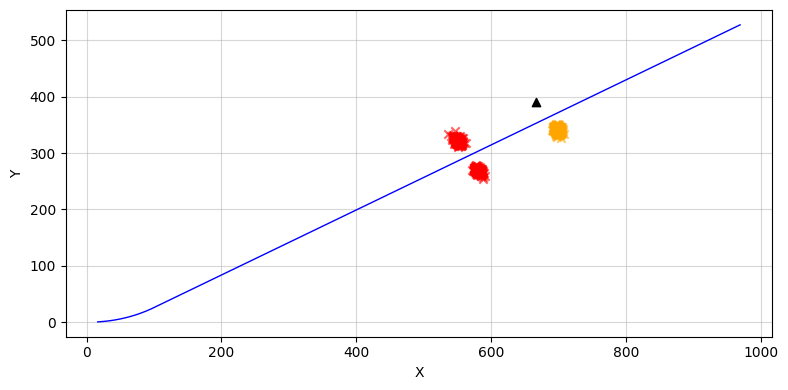

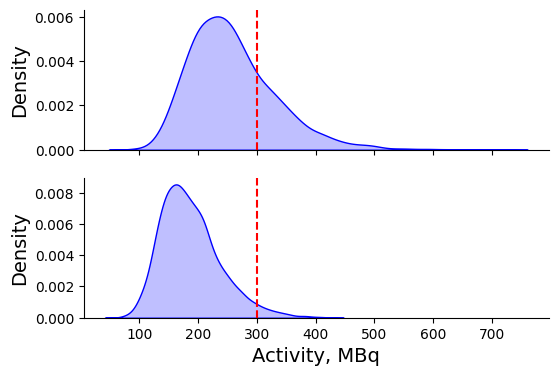

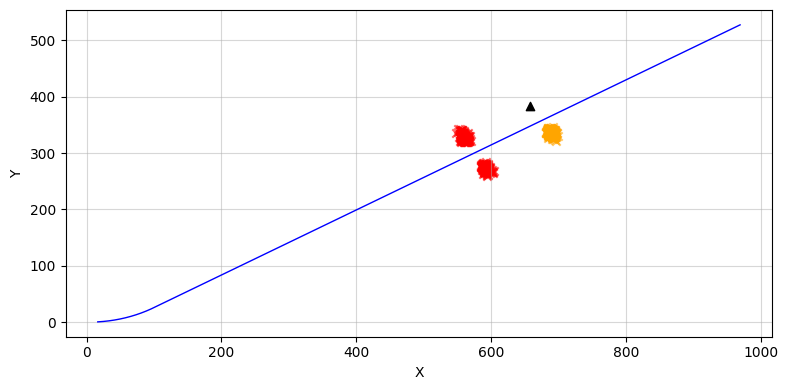

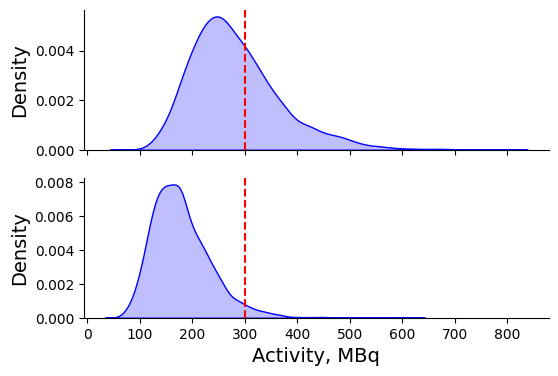

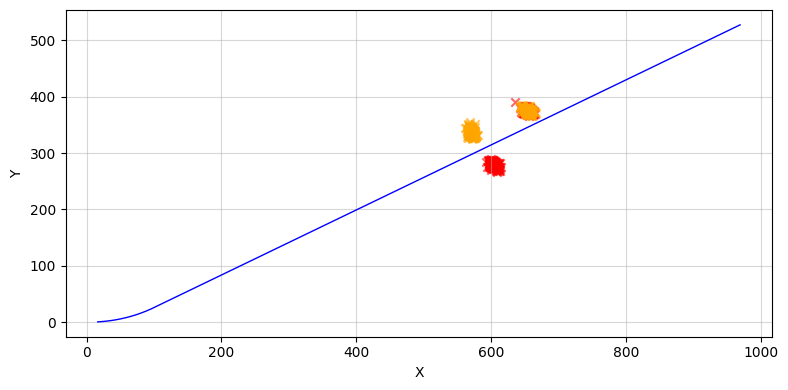

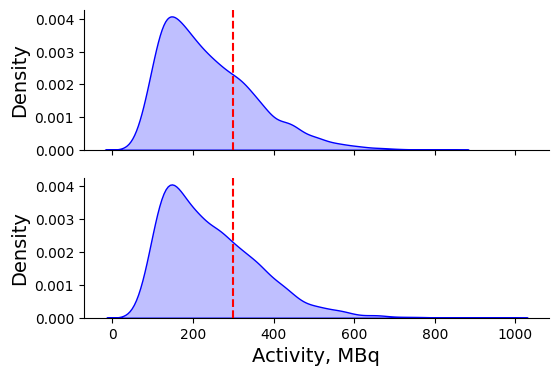

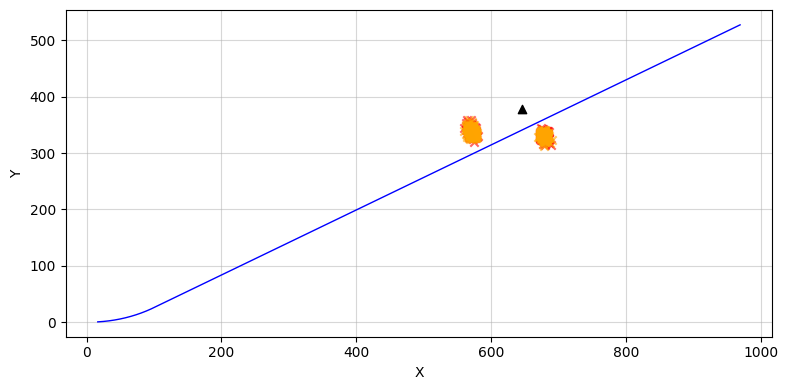

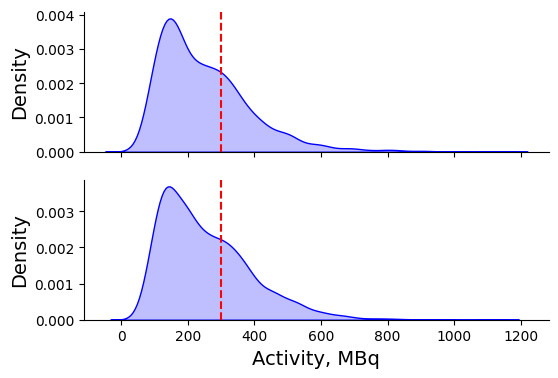

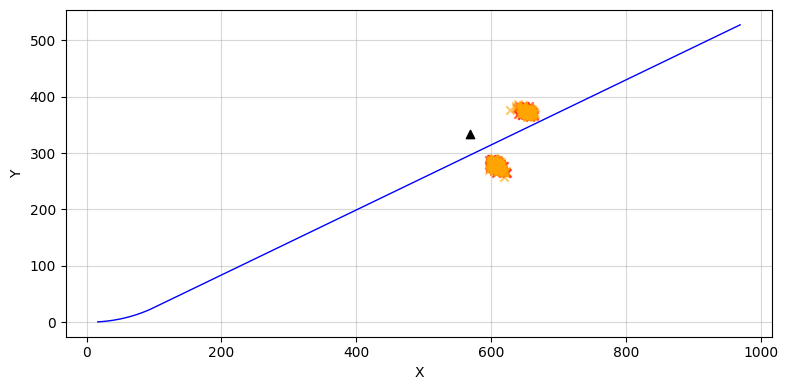

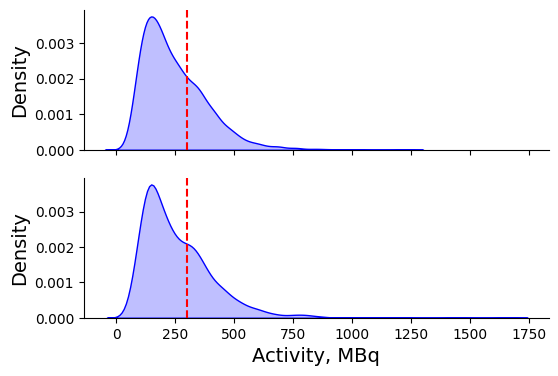

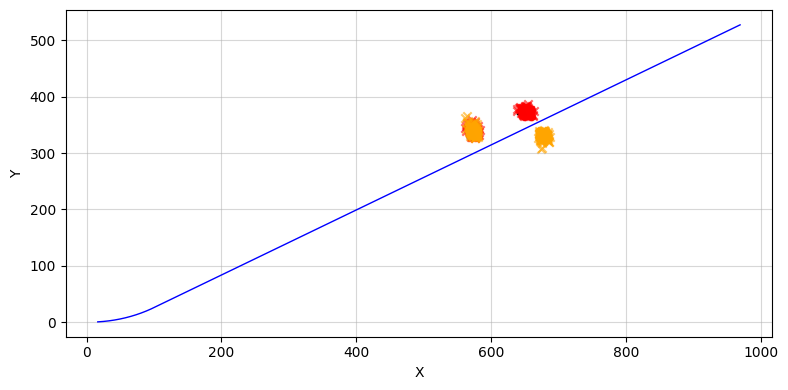

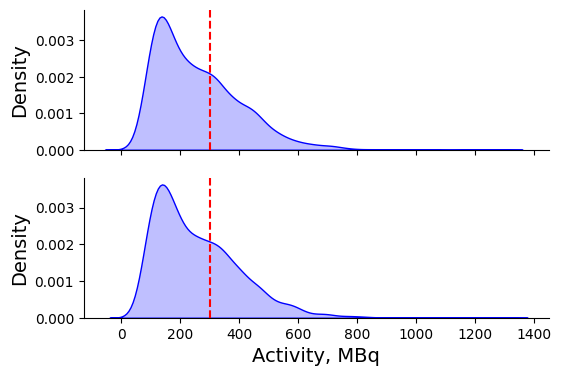

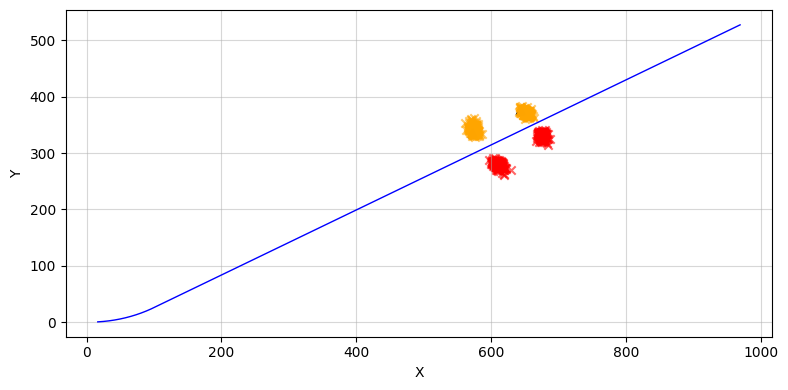

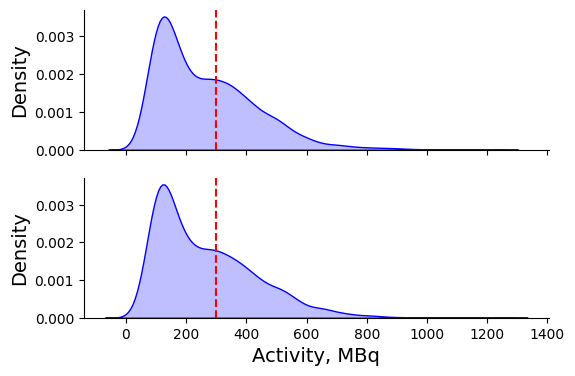

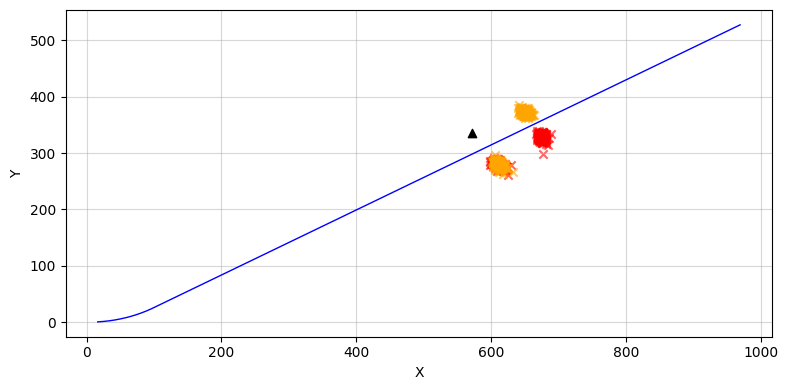

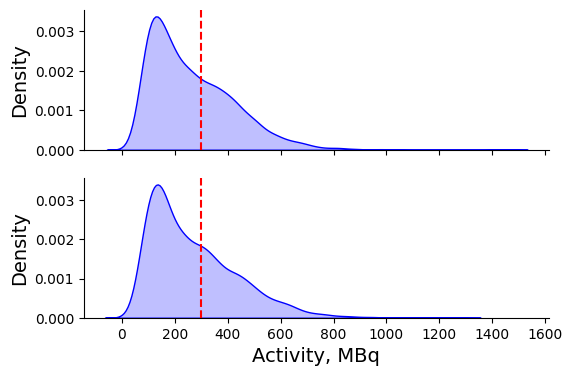

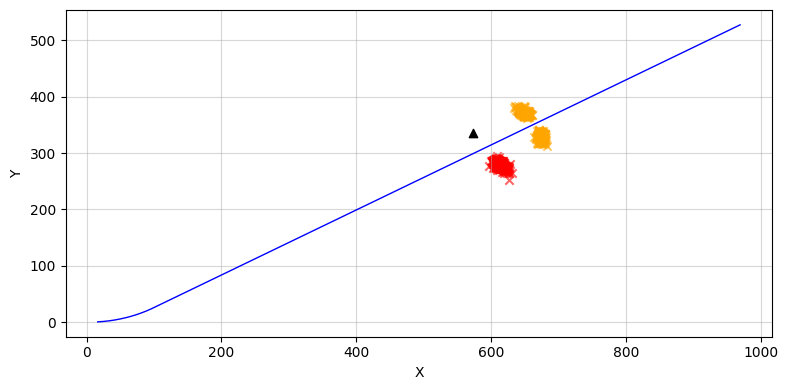

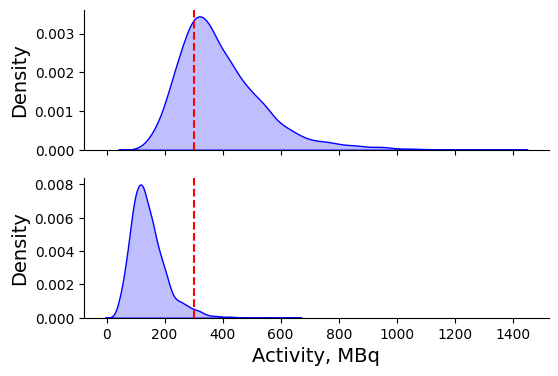

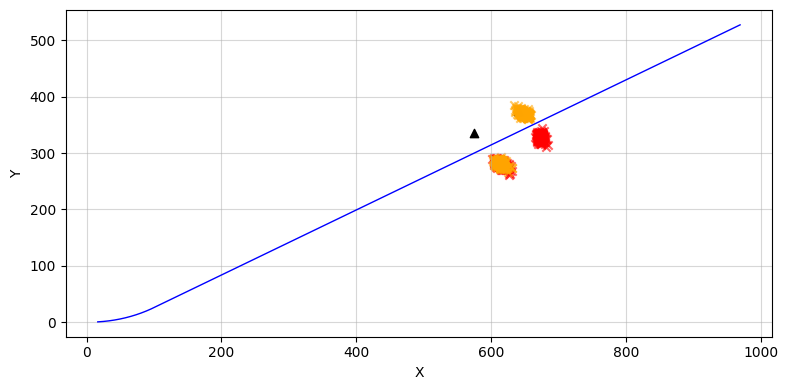

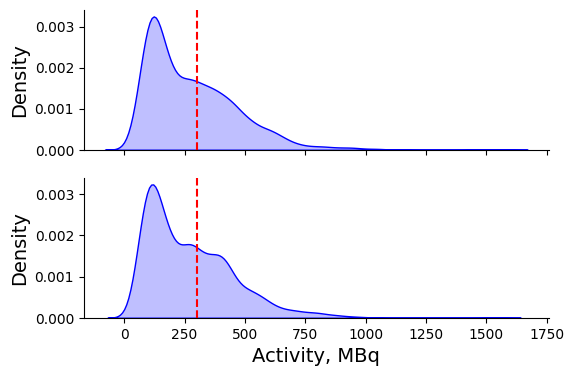

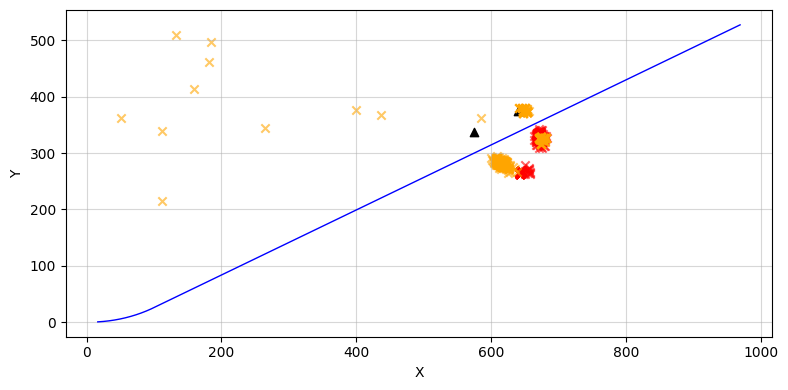

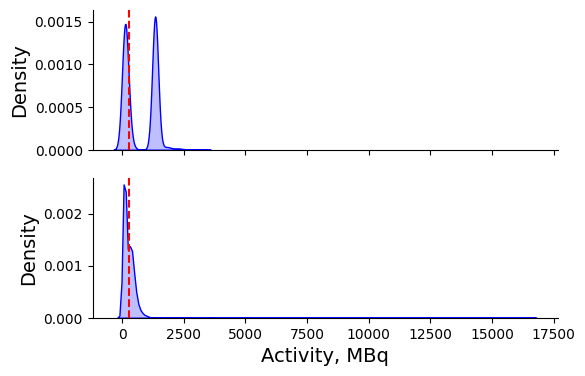

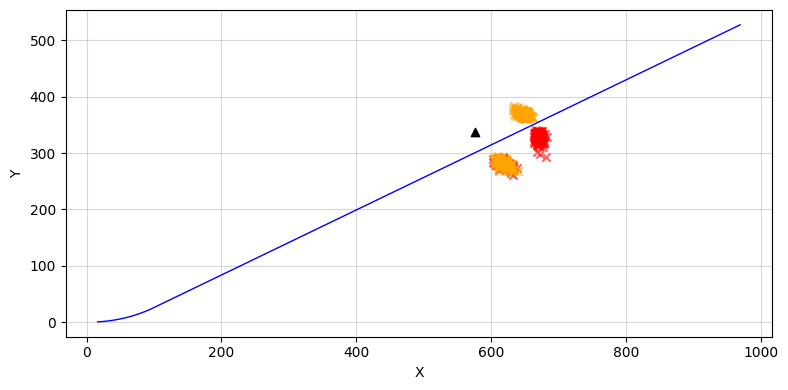

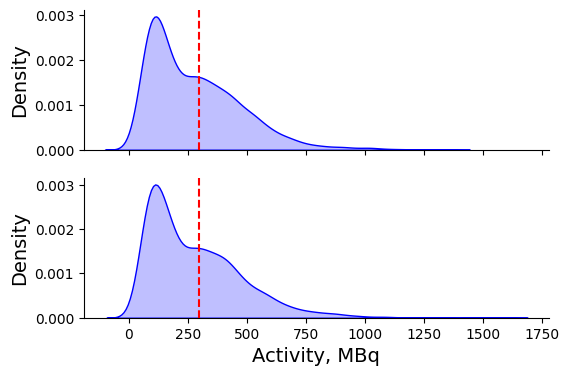

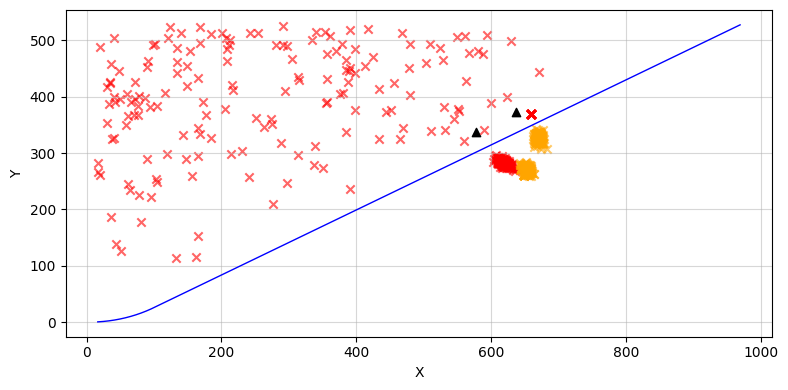

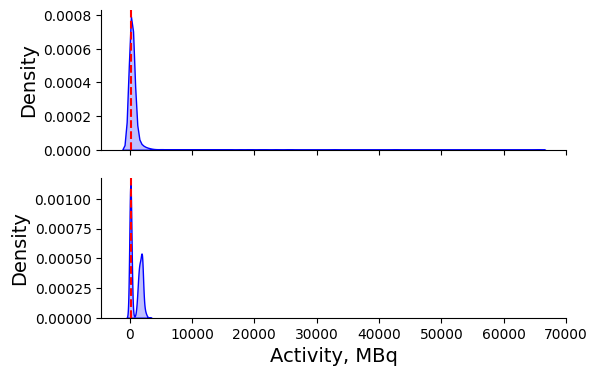

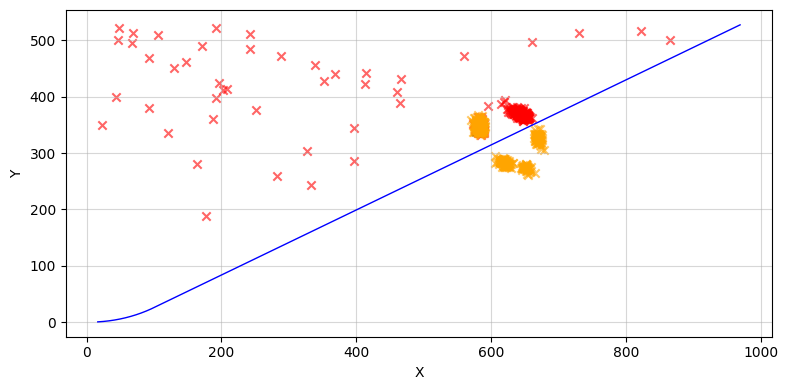

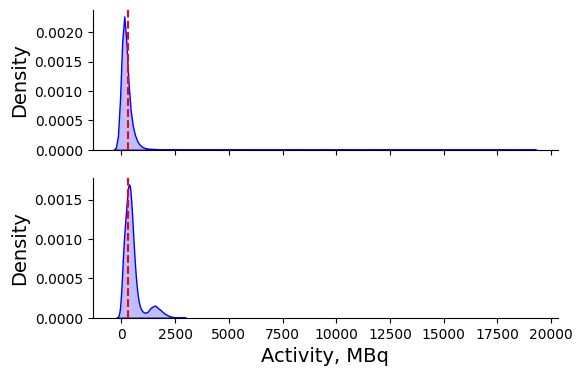

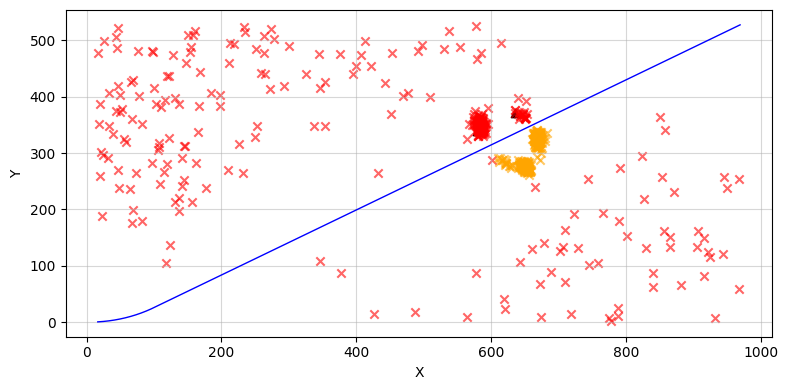

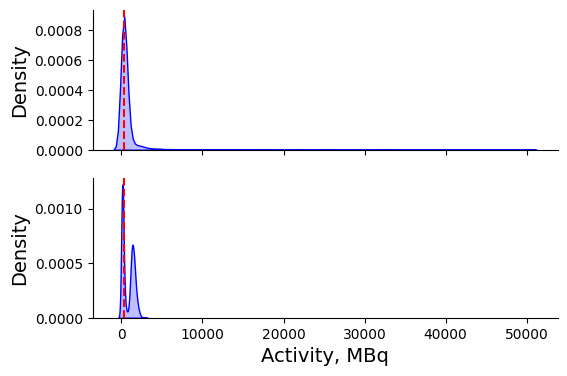

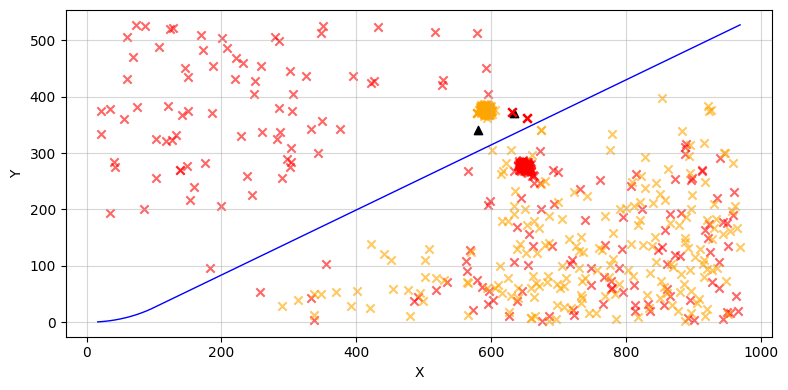

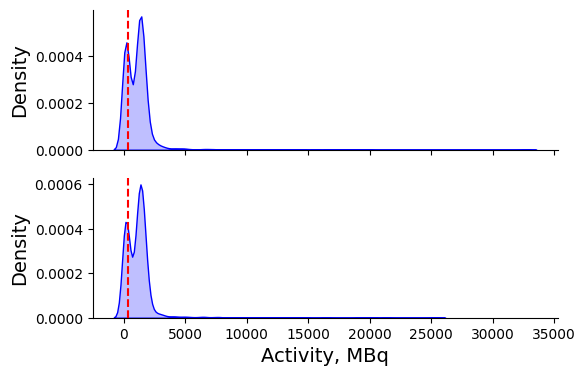

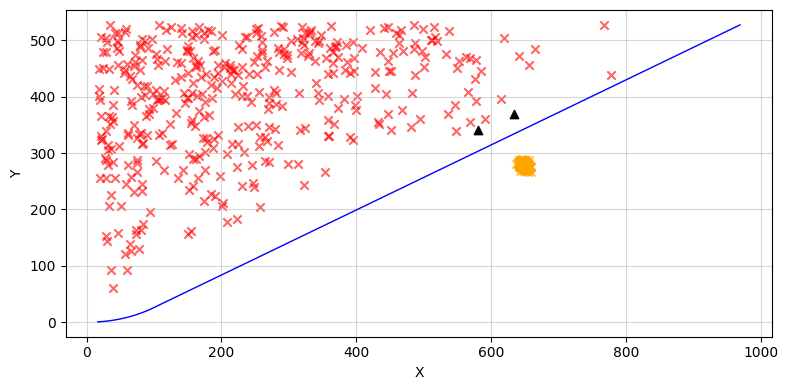

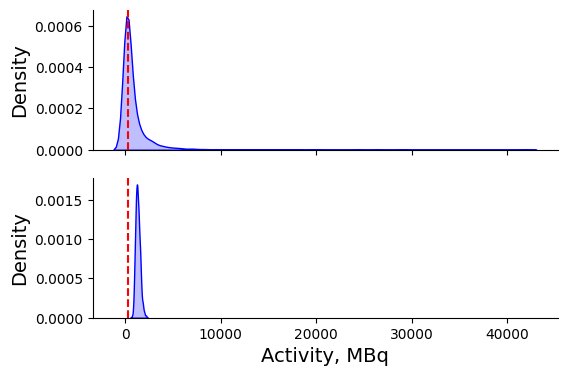

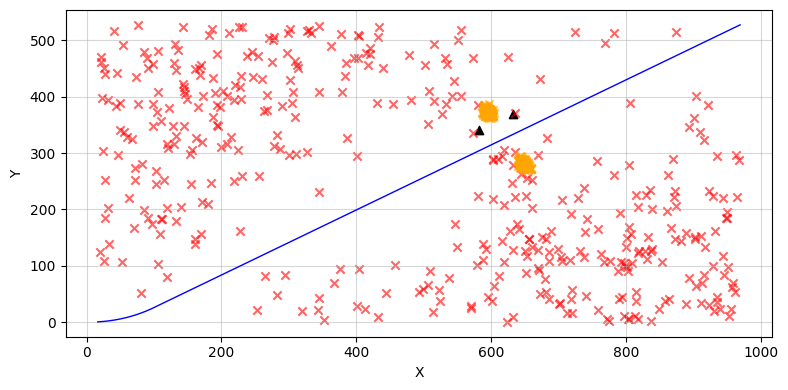

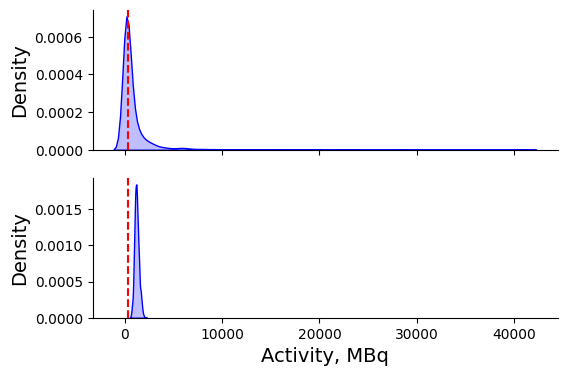

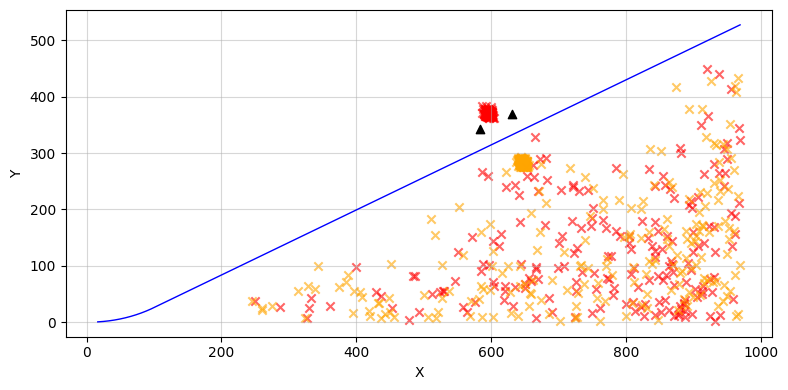

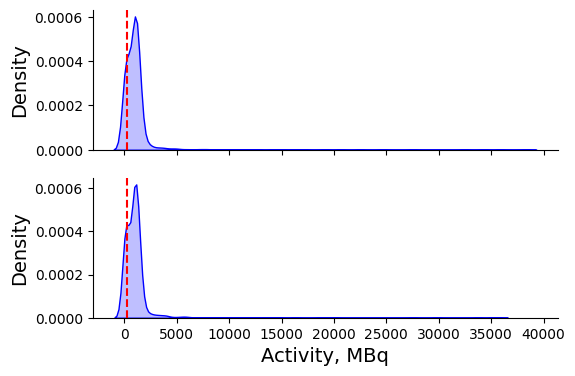

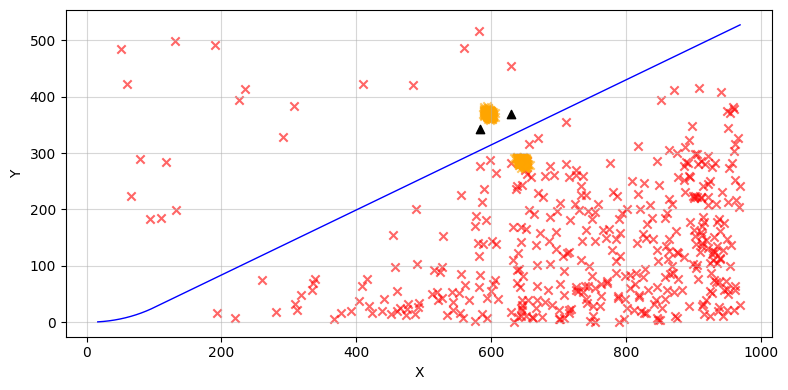

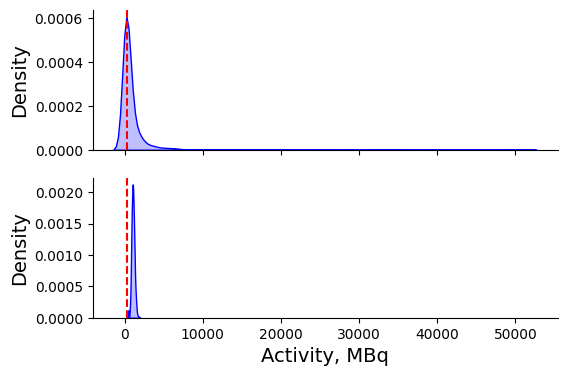

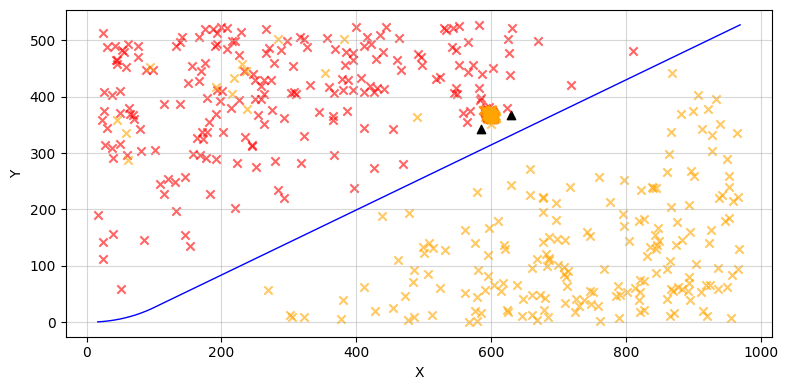

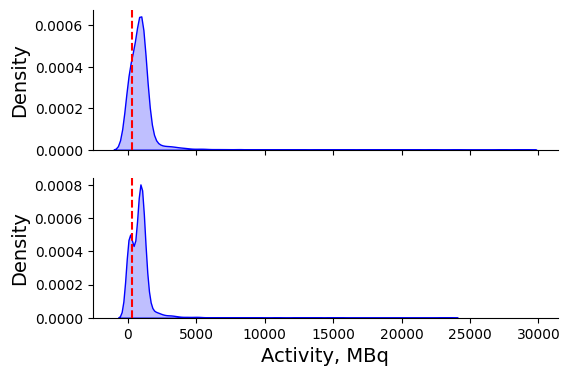

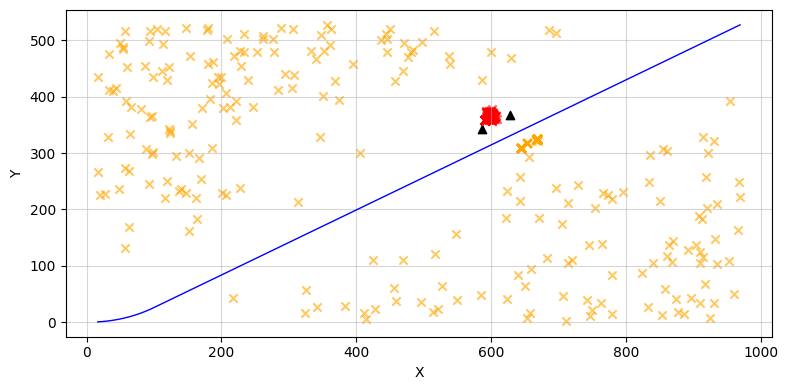

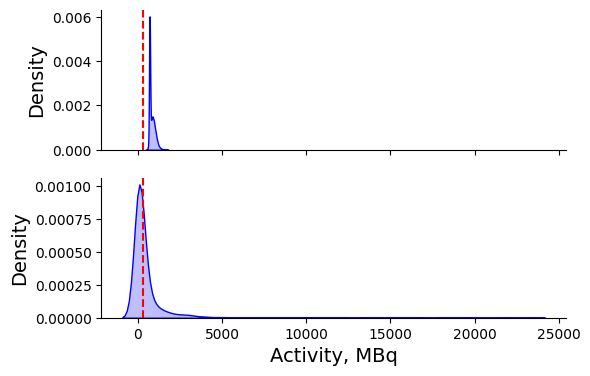

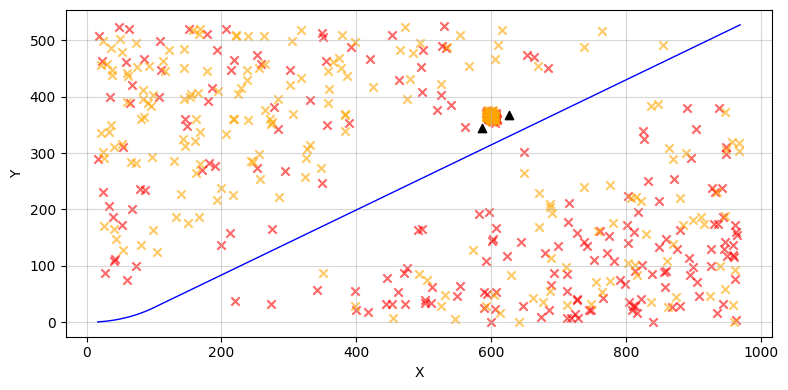

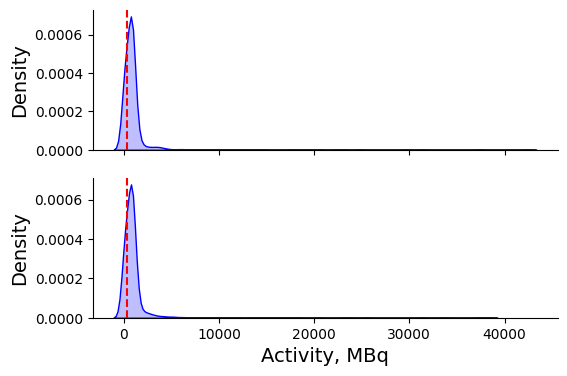

In [37]:
for k, v in result_dict.items():

    posterior = v['traces'][0].posterior
    n_sources = posterior.sizes["sources"]
    act_samples = {}
    
    for i in range(n_sources):
        act_samples[i+1] = (
            posterior["act_src"]
            .sel(sources=i)
            .values
            .reshape(-1)
        )
    
    x_samples = posterior.x_src.stack(sample=("chain","draw")).transpose("sources","sample").values
    y_samples = posterior.y_src.stack(sample=("chain","draw")).transpose("sources","sample").values

    ref_coords_x = [v['real_params'][j+1].get("x") for j in range(len(v['real_params']))]
    ref_coords_y = [v['real_params'][j+1].get("y") for j in range(len(v['real_params']))]

    plot_location(
        v['df'],
        ref_coords_x,
        ref_coords_y,
        x_samples,
        y_samples
    )

    plot_act_density(act_samples, true_act=real_acts)

## Residuals

Plot the mean residual of the different scenarios (mean across the 10 simulation runs!)

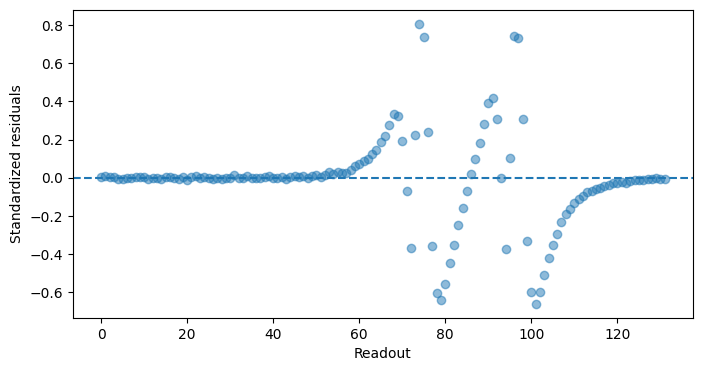

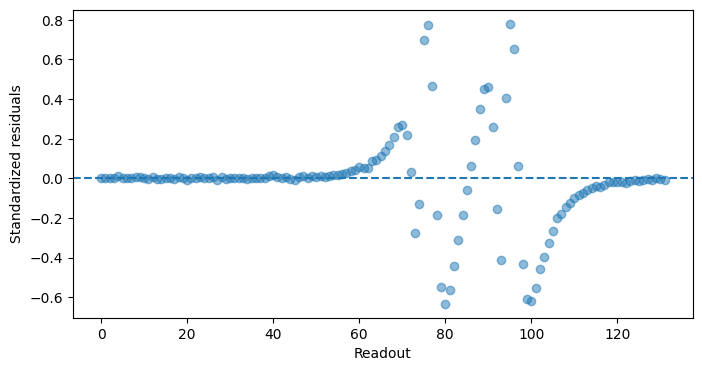

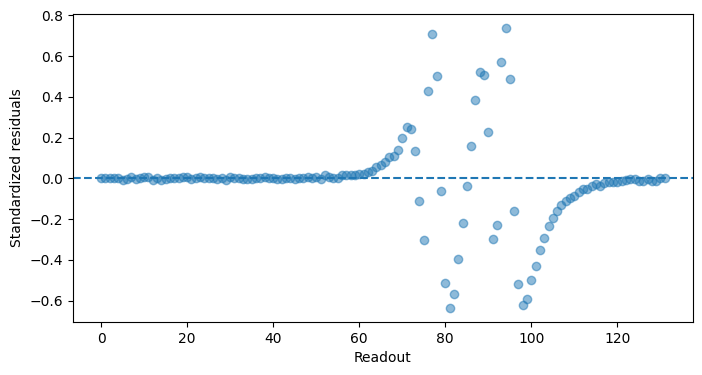

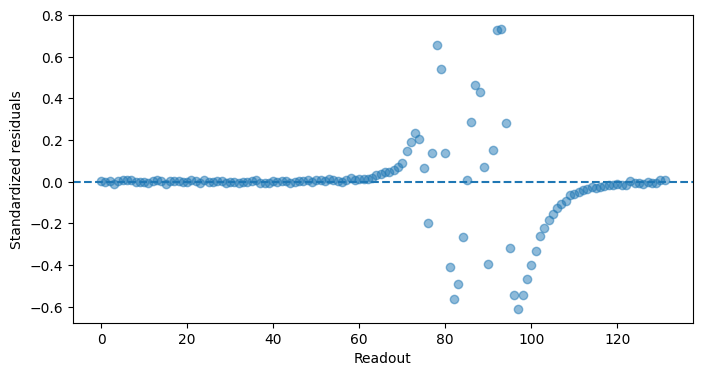

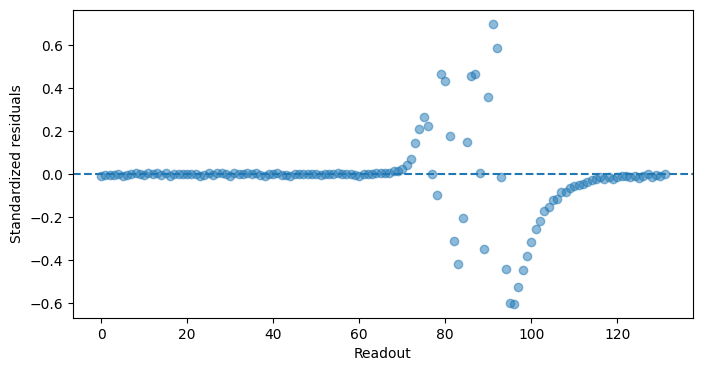

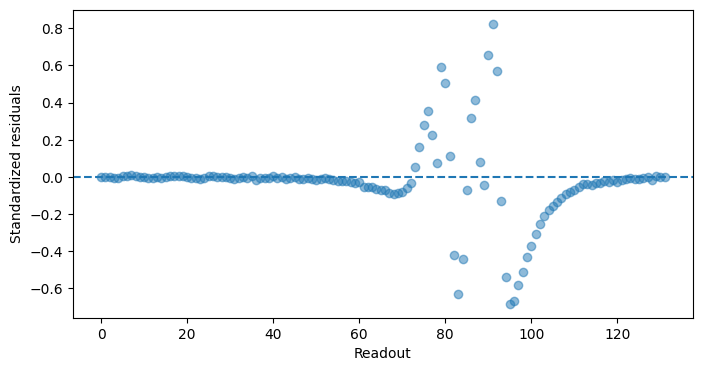

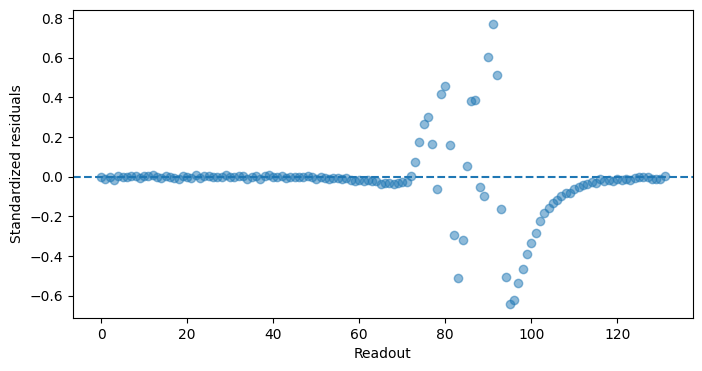

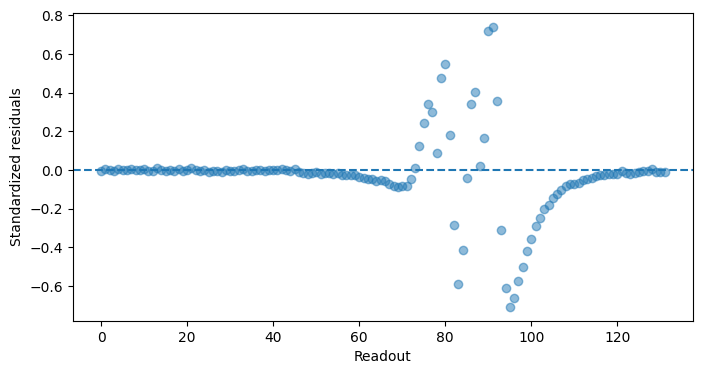

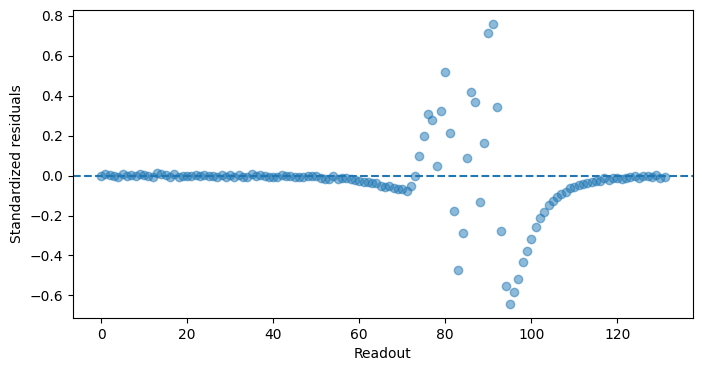

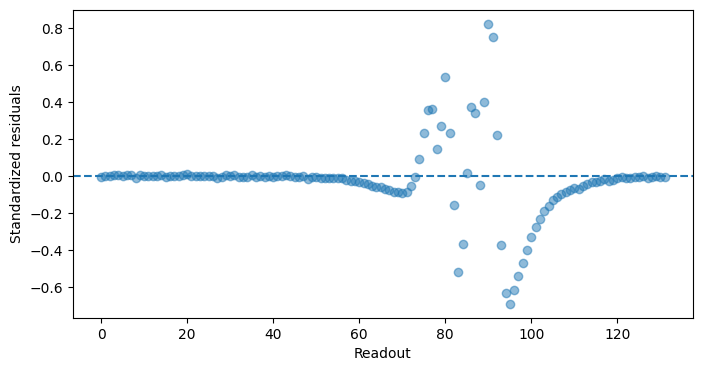

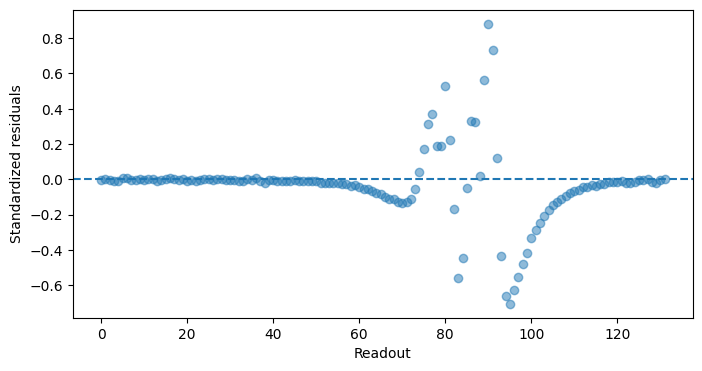

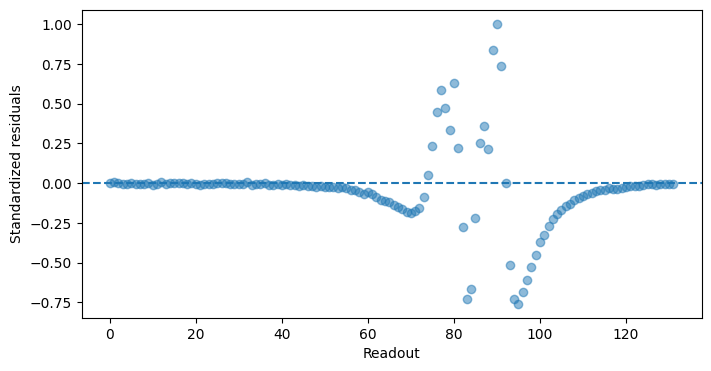

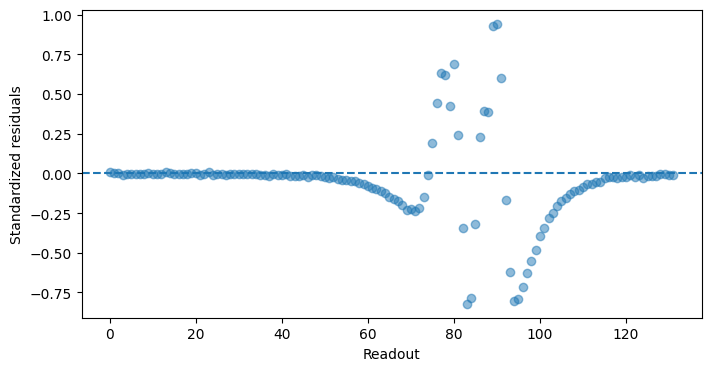

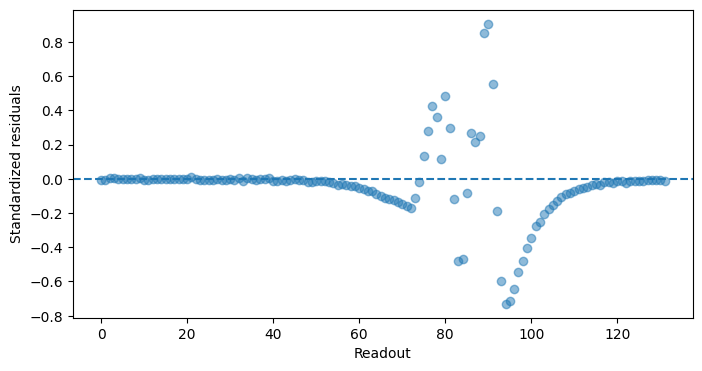

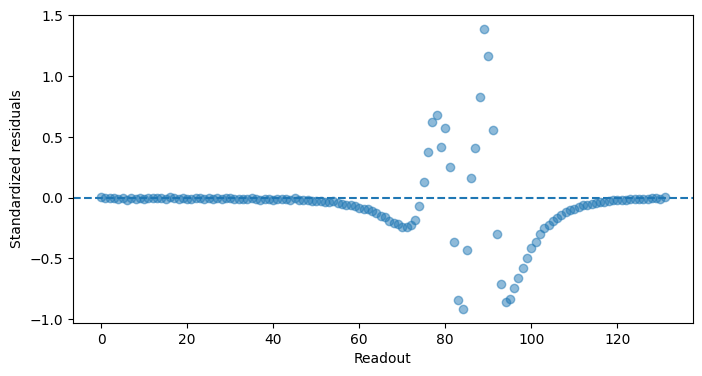

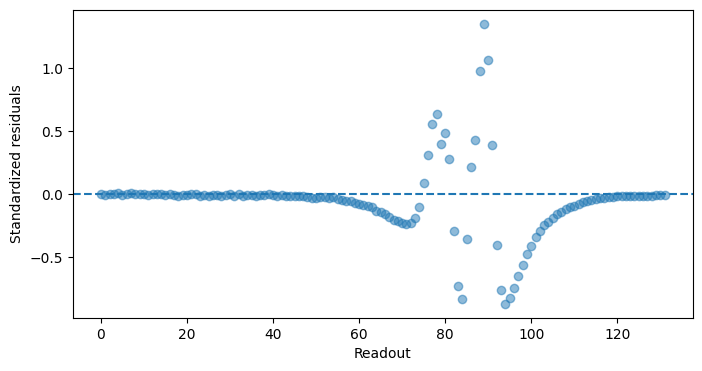

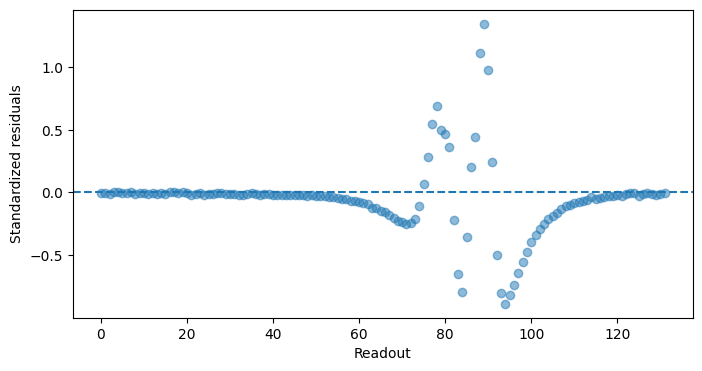

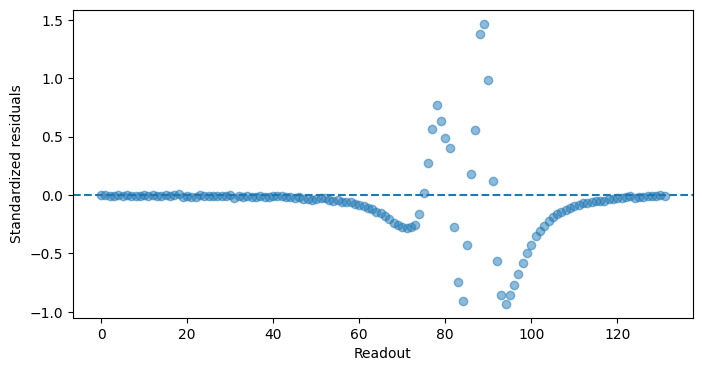

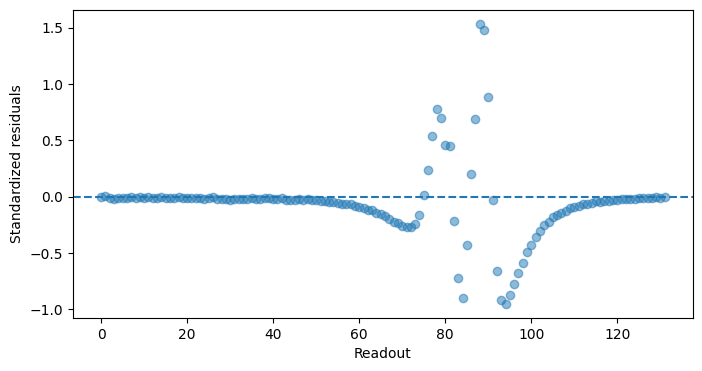

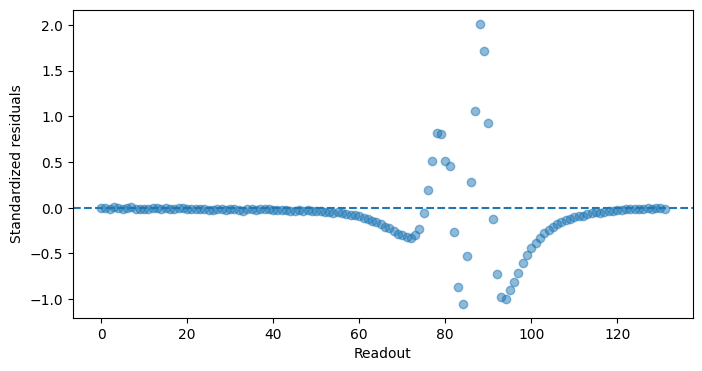

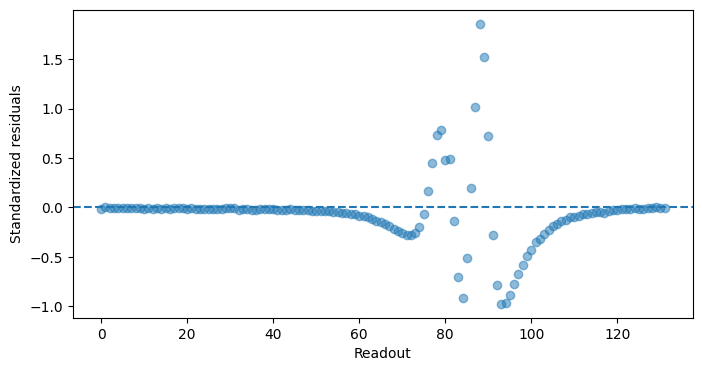

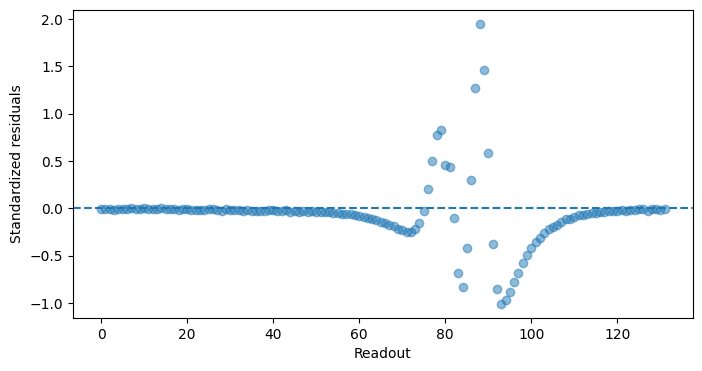

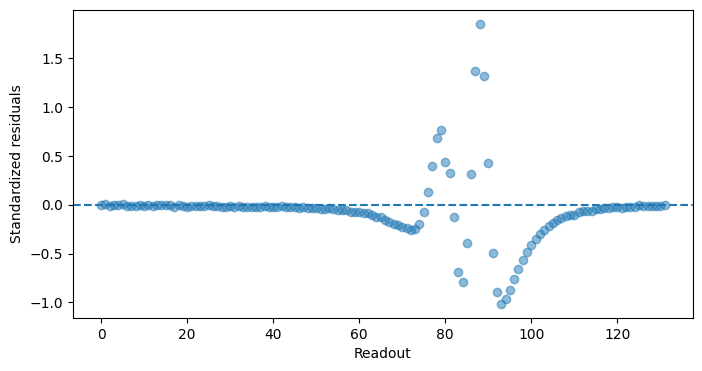

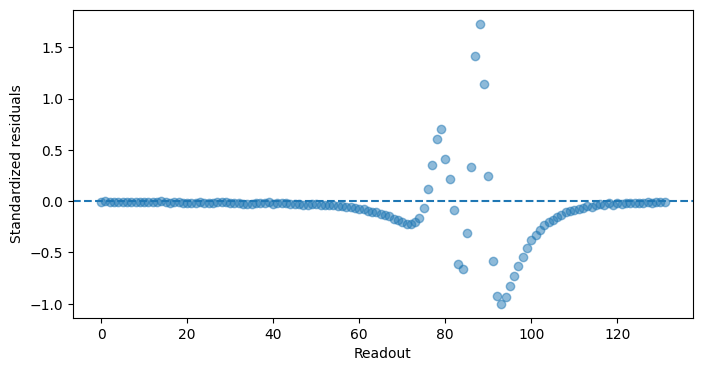

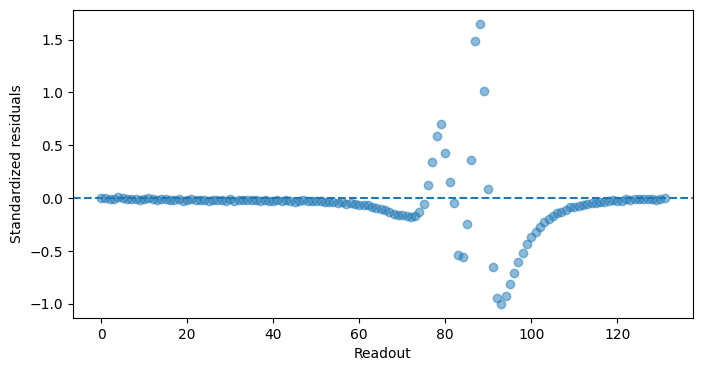

In [38]:
for k, v in result_dict.items():

    pred_cps = np.array([
        v['traces'][j].posterior_predictive.predicted_cps
        for j
        in range(len(v['traces']))
    ]).mean(axis=1)

    pred_cps_reshaped = np.vstack(([item for item in pred_cps]))
    cps_ = v['df'].ROI_P
        
    lambda_mean = pred_cps_reshaped.mean(axis=0)
    residuals = (cps_ - lambda_mean)/np.sqrt(lambda_mean)

    plt.figure(figsize=(8,4))
    plt.scatter(range(len(residuals)), residuals, alpha=0.5)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Readout")
    plt.ylabel("Standardized residuals")
    plt.show()